# UFC Fight Prediction Based on Striking Performance

Introduction to Data Science

Bobby B

!


The Ultimate Fighter Championship (UFC) is the leading mixed martial arts (MMA) promotion in the world. It puts on blockbuster performances across the globe garnering major viewership and major profits. But the thing that separates the UFC from other fight promotions like Bellator, Fury, and the PFL isn’t the highly polished production or its many advertisers. What makes UFC stand apart from its competitors is the level of talent on their roster. From strawweight all the way to heavyweight, the talent of signed UFC athletes is next to none.

UFC athletes need to be a ‘complete fighter’. Meaning, they need to be able to strike, grapple, and be in peak physical condition. The best of the best typically excels in all three facets. This project looks to challenge widely accepted notions and test it rigorously using data science methods to solve a sports analytics problem.

This project will take a <u>single aspect</u> of a fighter’s **striking performance from a previous fight** and will test to see if it alone is sufficient to predict the winner of a fight. 

[Link to the dataset source](https://www.kaggle.com/datasets/rajeevw/ufcdata?select=data.csv)


---
## Create .venv for this project & import libraries

I'm experimenting with using .venv for Python virtual environments.
Since my libraries are not in this .venv, I need to add them. ```Ctrl```+```~``` to open terminal.
1. Create the virtual environment (.venv).
    
    a. VSCode has a way to create one using the GUI.
    
    b. Powershell method: ```python -m venv .venv```.
2. Activate it using ```.venv\Scripts\activate```.
3. Install the project packages: ```pip install numpy pandas matplotlib seaborn ipython requests beautifulsoup4 scikit-learn```.
4. Connect the .venv to Jupyter: ```python -m ipykernel install --user --name="bagley_ufc_striking_project"```
    
    a. I'm unsure if this step was necessary.

The goal of this exercise is to adhere to industry standards in using **virtual environments**, and to keep my global environment clean. It is poor practice to use the *global python kernel* due to software/library version issues between different projects. Get accustomed to creating a virtual environment for each project from now on.

In [1]:
import numpy as np
import pandas as pd
# Show all columns
pd.set_option('display.max_columns', None)
# Show all rows
pd.set_option('display.max_rows', None)
# Increase the width of each column 
pd.set_option('display.max_colwidth', None)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report

# Web scraping libraries if needed.
#import requests
#from bs4 import BeautifulSoup

Above are the anticipated libraries I will require for this project. If I decide to grab additional fight data, I will web scrape with these libraries: ```beautifulsoup4``` & ```requests```. 

# Problem Definition

**Question**: Is striking performance from previous fights an adequate indicator of success (winning a fight) in mixed martial arts competition?

**Goal**: Binary classification to predict the fight's winner.

**Scope**: Scope is narrowed to the UFC *Modern Era* (fights post- 2015).


# Data Acquisition

For this project I will use a publicly available dataset from Kaggle titled: [UFC-Fight historical data from 1993 to 2021](https://www.kaggle.com/datasets/rajeevw/ufcdata?select=data.csv). It contains over a thousand rows and 100+ columns of raw fight data from the UFC’s inception in 1993 to 2021. There are 3 versions of this dataset available. The description provided is taken directly from the *‘Detail’* tab on the dataset’s Kaggle page.

There are many iterations of this dataset. Specifically, I'm going to use the following file:
* [data.csv](https://www.kaggle.com/datasets/rajeevw/ufcdata?select=data.csv) - This is the partially processed file. All feature engineering has been included and every row is a compilation of info about each fighter up until that fight. The data has not been one hot encoded or processed for missing data. You can use this file to do your own processing and further feature engineering.

The task of this project is **binary classification**: the fight’s winner. I will engineer a binary column (0 or 1) from the existing Winner column to be the target for my model(s).
This dataset is ideal because it contains a rich set of pre-fight average statistics (specifically striking) for both athletes (example ```B_avg_SIG_STR_pct```, ```B_avg_opp_SIG_STR_att```) which are key for attempting to predict the outcome based on striking performance.

In [2]:
# Read dataset to a dataframe.
ufc_data = pd.read_csv('data/data.csv')

# Take a peak at the data.
ufc_data.head()

,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_TD_pct,B_avg_opp_TD_pct,B_avg_SUB_ATT,B_avg_opp_SUB_ATT,B_avg_REV,B_avg_opp_REV,B_avg_SIG_STR_att,B_avg_SIG_STR_landed,B_avg_opp_SIG_STR_att,B_avg_opp_SIG_STR_landed,B_avg_TOTAL_STR_att,B_avg_TOTAL_STR_landed,B_avg_opp_TOTAL_STR_att,B_avg_opp_TOTAL_STR_landed,B_avg_TD_att,B_avg_TD_landed,B_avg_opp_TD_att,B_avg_opp_TD_landed,B_avg_HEAD_att,B_avg_HEAD_landed,B_avg_opp_HEAD_att,B_avg_opp_HEAD_landed,B_avg_BODY_att,B_avg_BODY_landed,B_avg_opp_BODY_att,B_avg_opp_BODY_landed,B_avg_LEG_att,B_avg_LEG_landed,B_avg_opp_LEG_att,B_avg_opp_LEG_landed,B_avg_DISTANCE_att,B_avg_DISTANCE_landed,B_avg_opp_DISTANCE_att,B_avg_opp_DISTANCE_landed,B_avg_CLINCH_att,B_avg_CLINCH_landed,B_avg_opp_CLINCH_att,B_avg_opp_CLINCH_landed,B_avg_GROUND_att,B_avg_GROUND_landed,B_avg_opp_GROUND_att,B_avg_opp_GROUND_landed,B_avg_CTRL_time(seconds),B_avg_opp_CTRL_time(seconds),B_total_time_fought(seconds),B_total_rounds_fought,B_total_title_bouts,B_current_win_streak,B_current_lose_streak,B_longest_win_streak,B_wins,B_losses,B_draw,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_avg_KD,R_avg_opp_KD,R_avg_SIG_STR_pct,R_avg_opp_SIG_STR_pct,R_avg_TD_pct,R_avg_opp_TD_pct,R_avg_SUB_ATT,R_avg_opp_SUB_ATT,R_avg_REV,R_avg_opp_REV,R_avg_SIG_STR_att,R_avg_SIG_STR_landed,R_avg_opp_SIG_STR_att,R_avg_opp_SIG_STR_landed,R_avg_TOTAL_STR_att,R_avg_TOTAL_STR_landed,R_avg_opp_TOTAL_STR_att,R_avg_opp_TOTAL_STR_landed,R_avg_TD_att,R_avg_TD_landed,R_avg_opp_TD_att,R_avg_opp_TD_landed,R_avg_HEAD_att,R_avg_HEAD_landed,R_avg_opp_HEAD_att,R_avg_opp_HEAD_landed,R_avg_BODY_att,R_avg_BODY_landed,R_avg_opp_BODY_att,R_avg_opp_BODY_landed,R_avg_LEG_att,R_avg_LEG_landed,R_avg_opp_LEG_att,R_avg_opp_LEG_landed,R_avg_DISTANCE_att,R_avg_DISTANCE_landed,R_avg_opp_DISTANCE_att,R_avg_opp_DISTANCE_landed,R_avg_CLINCH_att,R_avg_CLINCH_landed,R_avg_opp_CLINCH_att,R_avg_opp_CLINCH_landed,R_avg_GROUND_att,R_avg_GROUND_landed,R_avg_opp_GROUND_att,R_avg_opp_GROUND_landed,R_avg_CTRL_time(seconds),R_avg_opp_CTRL_time(seconds),R_total_time_fought(seconds),R_total_rounds_fought,R_total_title_bouts,R_current_win_streak,R_current_lose_streak,R_longest_win_streak,R_wins,R_losses,R_draw,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
0,Adrian Yanez,Gustavo Lopez,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Bantamweight,0.000,0.0,0.420000,0.49500,0.330,0.36000,0.500,1.0000,0.00,0.0,50.0000,20.0000,84.000,45.0000,76.5000,41.000,114.000,64.00,1.500,1.0,9.0,6.500,39.500,11.000,63.0000,27.500,7.5000,7.0000,12.0000,9.0000,3.000,2.000,9.000,8.500,35.0000,12.5,43.5000,17.5000,10.5000,4.5000,4.0000,3.00,4.5000,3.000,36.50,24.50,34.00,277.5000,531.5,4,0,0,1,1,1,1,0,0,0,0,0,1,0,Orthodox,165.10,170.18,135.0,1.000000,0.000000,0.500000,0.460000,0.000000,0.00000,0.000000,0.00000,0.00000,0.00,34.000000,17.000000,13.00000,6.000000,35.000000,18.000000,16.000000,9.000000,0.000000,0.000000,3.000000,0.000000,32.00000,15.000000,11.000000,5.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,33.000000,16.000000,12.000000,6.000000,1.000000,1.000000,1.0000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,54.000000,166.000000,1,0,1,0,1,1,0,0,0,0,0,1,0,0,Orthodox,170.18,177.80,135.0,31.0,27.0
1,Trevin Giles,Roman Dolidze,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Middleweight,0.500,0.0,0.660000,0.30500,0.300,0.50000,1.500,0.0000,0.00,0.0,65.5000,35.0000,50.000,16.5000,113.5000,68.500,68.500,29.00,2.500,1.5,0.5,0.500,46.000,20.000,36.0000,7.500,12.0000,8.0000,8.0000,3.0000,7.500,7.000,6.000,6.000,58.0000,30.0,48.0000,15.5000,0.5000,0.5000,0.5000,0.50,7

In [3]:
#list all columns
ufc_data.columns.tolist()


['R_fighter',
 'B_fighter',
 'Referee',
 'date',
 'location',
 'Winner',
 'title_bout',
 'weight_class',
 'B_avg_KD',
 'B_avg_opp_KD',
 'B_avg_SIG_STR_pct',
 'B_avg_opp_SIG_STR_pct',
 'B_avg_TD_pct',
 'B_avg_opp_TD_pct',
 'B_avg_SUB_ATT',
 'B_avg_opp_SUB_ATT',
 'B_avg_REV',
 'B_avg_opp_REV',
 'B_avg_SIG_STR_att',
 'B_avg_SIG_STR_landed',
 'B_avg_opp_SIG_STR_att',
 'B_avg_opp_SIG_STR_landed',
 'B_avg_TOTAL_STR_att',
 'B_avg_TOTAL_STR_landed',
 'B_avg_opp_TOTAL_STR_att',
 'B_avg_opp_TOTAL_STR_landed',
 'B_avg_TD_att',
 'B_avg_TD_landed',
 'B_avg_opp_TD_att',
 'B_avg_opp_TD_landed',
 'B_avg_HEAD_att',
 'B_avg_HEAD_landed',
 'B_avg_opp_HEAD_att',
 'B_avg_opp_HEAD_landed',
 'B_avg_BODY_att',
 'B_avg_BODY_landed',
 'B_avg_opp_BODY_att',
 'B_avg_opp_BODY_landed',
 'B_avg_LEG_att',
 'B_avg_LEG_landed',
 'B_avg_opp_LEG_att',
 'B_avg_opp_LEG_landed',
 'B_avg_DISTANCE_att',
 'B_avg_DISTANCE_landed',
 'B_avg_opp_DISTANCE_att',
 'B_avg_opp_DISTANCE_landed',
 'B_avg_CLINCH_att',
 'B_avg_CLINCH_lande

In [4]:
# Check datatypes
ufc_data.dtypes

R_fighter                        object
B_fighter                        object
Referee                          object
date                             object
location                         object
Winner                           object
title_bout                         bool
weight_class                     object
B_avg_KD                        float64
B_avg_opp_KD                    float64
B_avg_SIG_STR_pct               float64
B_avg_opp_SIG_STR_pct           float64
B_avg_TD_pct                    float64
B_avg_opp_TD_pct                float64
B_avg_SUB_ATT                   float64
B_avg_opp_SUB_ATT               float64
B_avg_REV                       float64
B_avg_opp_REV                   float64
B_avg_SIG_STR_att               float64
B_avg_SIG_STR_landed            float64
B_avg_opp_SIG_STR_att           float64
B_avg_opp_SIG_STR_landed        float64
B_avg_TOTAL_STR_att             float64
B_avg_TOTAL_STR_landed          float64
B_avg_opp_TOTAL_STR_att         float64


In [5]:
ufc_data.shape

(6012, 144)

# Data Preparation & Wrangling

## Data Cleaning

0. Remove fight data pre-2015. ✅

1. Drop unnecessary *admin* columns and features unrelated to **striking**. ✅

2. Remove duplicates. ✅
 
3. Correct datatypes. ✅

4. Handle missing values. ✅

5. Check for outliers. ✅

### Filter by ```date```

In [6]:
# First, drop rows where date is less than 2015-07-01.

# Date is a an object datatype, so convert to datetime first.
ufc_data['date'] = pd.to_datetime(ufc_data['date'])
# Check my work
print(ufc_data['date'].dtype)


datetime64[ns]


In [7]:
# Filter for dates after 2015-07-01
ufc_data = ufc_data[ufc_data['date'] >= '2015-07-01']
# Check my work
print(f'Oldest date: {ufc_data['date'].min()}')
print(f'Most recent date: {ufc_data['date'].max()}')
print(f'The new shape of the dataframe: {ufc_data.shape}')

Oldest date: 2015-07-11 00:00:00
Most recent date: 2021-03-20 00:00:00
The new shape of the dataframe: (2748, 144)


### Drop features unrelated to striking

In [8]:
# Drop unnecessary columns unrelated to striking.
columns_to_drop = [
 'Referee',
 'location',
 'title_bout',
 'B_avg_TD_pct',
 'B_avg_opp_TD_pct',
 'B_avg_SUB_ATT',
 'B_avg_opp_SUB_ATT',
 'B_avg_REV',
 'B_avg_opp_REV',
 'B_avg_TD_att',
 'B_avg_TD_landed',
 'B_avg_opp_TD_att',
 'B_avg_opp_TD_landed',
 'B_avg_CTRL_time(seconds)',
 'B_avg_opp_CTRL_time(seconds)',
 'B_total_time_fought(seconds)',
 'B_total_rounds_fought',
 'B_total_title_bouts',
 'B_current_win_streak',
 'B_current_lose_streak',
 'B_longest_win_streak',
 'B_wins',
 'B_losses',
 'B_draw',
 'R_avg_TD_pct',
 'R_avg_opp_TD_pct',
 'R_avg_SUB_ATT',
 'R_avg_opp_SUB_ATT',
 'R_avg_REV',
 'R_avg_opp_REV',
 'R_avg_TD_att',
 'R_avg_TD_landed',
 'R_avg_opp_TD_att',
 'R_avg_opp_TD_landed',
 'R_avg_CTRL_time(seconds)',
 'R_avg_opp_CTRL_time(seconds)',
 'R_total_time_fought(seconds)',
 'R_total_rounds_fought',
 'R_total_title_bouts',
 'R_current_win_streak',
 'R_current_lose_streak',
 'R_longest_win_streak',
 'R_wins',
 'R_losses',
 'R_draw'
]

# Check columns to drop.
print(f'Columns to drop: {columns_to_drop}')
print(f'Number of columns to drop: {len(columns_to_drop)}')
print(f'Number of columns that should remain: {ufc_data.shape[1] - len(columns_to_drop)}')

# Drop the columns.
ufc_data.drop(columns=columns_to_drop, inplace=True)

# Check the shape of the dataframe after dropping columns.
print(f'New shape of the dataframe: {ufc_data.shape}')

Columns to drop: ['Referee', 'location', 'title_bout', 'B_avg_TD_pct', 'B_avg_opp_TD_pct', 'B_avg_SUB_ATT', 'B_avg_opp_SUB_ATT', 'B_avg_REV', 'B_avg_opp_REV', 'B_avg_TD_att', 'B_avg_TD_landed', 'B_avg_opp_TD_att', 'B_avg_opp_TD_landed', 'B_avg_CTRL_time(seconds)', 'B_avg_opp_CTRL_time(seconds)', 'B_total_time_fought(seconds)', 'B_total_rounds_fought', 'B_total_title_bouts', 'B_current_win_streak', 'B_current_lose_streak', 'B_longest_win_streak', 'B_wins', 'B_losses', 'B_draw', 'R_avg_TD_pct', 'R_avg_opp_TD_pct', 'R_avg_SUB_ATT', 'R_avg_opp_SUB_ATT', 'R_avg_REV', 'R_avg_opp_REV', 'R_avg_TD_att', 'R_avg_TD_landed', 'R_avg_opp_TD_att', 'R_avg_opp_TD_landed', 'R_avg_CTRL_time(seconds)', 'R_avg_opp_CTRL_time(seconds)', 'R_total_time_fought(seconds)', 'R_total_rounds_fought', 'R_total_title_bouts', 'R_current_win_streak', 'R_current_lose_streak', 'R_longest_win_streak', 'R_wins', 'R_losses', 'R_draw']
Number of columns to drop: 45
Number of columns that should remain: 99
New shape of the dat

In [9]:
# Check for duplicate rows.
duplicates = ufc_data.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

Number of duplicate rows: 0


**Previous total**: 144

**Features dropped**: 45

**New total features**: 99

To be further pared down in **Feature Selection**.

### Correct the datatypes

In [10]:
# Correct datatypes of all columns.
# First, get a list of columns with incorrect datatypes. Check for object datatypes that should be numeric.
object_columns = ufc_data.select_dtypes(include=['object']).columns.tolist()
print(f'All column datatypes: \n{ufc_data.dtypes}')
print(f'Object columns: {object_columns}')

All column datatypes: 
R_fighter                               object
B_fighter                               object
date                            datetime64[ns]
Winner                                  object
weight_class                            object
B_avg_KD                               float64
B_avg_opp_KD                           float64
B_avg_SIG_STR_pct                      float64
B_avg_opp_SIG_STR_pct                  float64
B_avg_SIG_STR_att                      float64
B_avg_SIG_STR_landed                   float64
B_avg_opp_SIG_STR_att                  float64
B_avg_opp_SIG_STR_landed               float64
B_avg_TOTAL_STR_att                    float64
B_avg_TOTAL_STR_landed                 float64
B_avg_opp_TOTAL_STR_att                float64
B_avg_opp_TOTAL_STR_landed             float64
B_avg_HEAD_att                         float64
B_avg_HEAD_landed                      float64
B_avg_opp_HEAD_att                     float64
B_avg_opp_HEAD_landed                

Object columns: ```'R_fighter'```, ```'B_fighter'```, ```'Winner'```, ```'weight_class'```, ```'B_Stance'```, ```'R_Stance'``` are all correctly set as objects.

Other columns appear to be correctly set as mostly floats (average values) and integers (binary columns).

There is one datetime column. 

There are **zero** boolean columns for now.

### Handle NaN and missing values
Fighters making their debut will have 0 or nan for their average stats. They need to be imputed with 0.

**CHANGE**. After discussing the matter of debut fighters with Dr. Zhu: 
* Check if there are a significant number of them.
* If not, drop them. Their presence will negatively affect my model.

Other than debuting fighters, impute any other missing values using **mean imputation**.

In [11]:
# This is old code to impute missing values with 0.
# --- IGNORE ---

## Handle NaN and missing values
## Fighters making their debut will have 0 or nan for their average stats. They need to be imputed with 0.
## Look for all columns that start with 'B_avg_' or 'R_avg_'
#avg_cols = [col for col in ufc_data.columns if col.startswith('B_avg_') or col.startswith('R_avg_')]

## Fill NaNs with 0
#ufc_data[avg_cols] = ufc_data[avg_cols].fillna(0)
## Check for any remaining NaN values
#print(ufc_data.isnull().sum())

#### Handling NaN / debutant fighters
Flag the record with a debutant fighter. Create a new flag column ```X_is_debut``` and set as 0 or 1 depending. This will explain to the model why a fighter's avg values are 0. The model can now learn if "debut status" itself is a predictive feature, which directly addresses Dr. Zhu's concern.

In [12]:
# Handle NaN and missing values in the case of debut fighters.
# 1. Get a list of all average columns for both fighters
r_avg_cols = [col for col in ufc_data.columns if col.startswith('R_avg_')]
b_avg_cols = [col for col in ufc_data.columns if col.startswith('B_avg_')]

# 2. Create the 'is_debut' flags BEFORE filling NaNs
# I use 'R_avg_KD' as a proxy. If it's NaN, all other avg stats are also NaN.
ufc_data['R_is_debut'] = ufc_data['R_avg_KD'].isna().astype(int)
ufc_data['B_is_debut'] = ufc_data['B_avg_KD'].isna().astype(int)

# 3. Now, safely fill all avg columns with 0
ufc_data[r_avg_cols] = ufc_data[r_avg_cols].fillna(0)
ufc_data[b_avg_cols] = ufc_data[b_avg_cols].fillna(0)

# Check my work
(ufc_data[['R_fighter', 'R_avg_SIG_STR_landed', 'R_is_debut', 'B_fighter', 'B_avg_SIG_STR_landed', 'B_is_debut']].head())

,R_fighter,R_avg_SIG_STR_landed,R_is_debut,B_fighter,B_avg_SIG_STR_landed,B_is_debut
0,Adrian Yanez,17.000000,0,Gustavo Lopez,20.0000,0
1,Trevin Giles,43.156250,0,Roman Dolidze,35.0000,0
2,Tai Tuivasa,30.375000,0,Harry Hunsucker,0.0000,1
3,Cheyanne Buys,0.000000,1,Montserrat Conejo,0.0000,1
4,Marion Reneau,44.362305,0,Macy Chiasson,57.9375,0


```B_Stance```, ```B_Reach_cms```, ```R_Stance```, ```R_Reach_cms``` are the only features left with missing data.

These are not critical features in my dataset. I kept them just in case they provided *interesting* insights or *nice-to-know*. It is possible to cold-deck 🧊 impute the data with actual values, but that would be time and labor intensive.

In [13]:
# Handle NaN values in 'B_Stance', 'B_Reach_cms', 'R_Stance', 'R_Reach_cms' if necessary.
# These features were always nice to have, but not necessary for the model. Drop all of the features.
ufc_data.drop(columns=['B_Stance', 'B_Reach_cms', 'R_Stance', 'R_Reach_cms'], inplace=True)
ufc_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2748 entries, 0 to 2747
Data columns (total 97 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   R_fighter                     2748 non-null   object        
 1   B_fighter                     2748 non-null   object        
 2   date                          2748 non-null   datetime64[ns]
 3   Winner                        2748 non-null   object        
 4   weight_class                  2748 non-null   object        
 5   B_avg_KD                      2748 non-null   float64       
 6   B_avg_opp_KD                  2748 non-null   float64       
 7   B_avg_SIG_STR_pct             2748 non-null   float64       
 8   B_avg_opp_SIG_STR_pct         2748 non-null   float64       
 9   B_avg_SIG_STR_att             2748 non-null   float64       
 10  B_avg_SIG_STR_landed          2748 non-null   float64       
 11  B_avg_opp_SIG_STR_att         2748 

### Outliers Gameplan
I have so many numeric columns, making boxplots of each one is not an optimal solution (I did it. It's ridiculous).

Break this down in 3 steps to try and make it more manageable:
1. Use ```describe()``` to look for obvious mistakes.
2. Standardize the numeric values; check if $Zscore > |3|$.
3. Narrow down my visualizations to the flagged columns ($Zscore > |3|$).

I need to really think about if I'm going to drop something regardless of outlier presence. These outliers can be indicators of *star performers* and could contribute insight to my analysis.

**ASK DR. ZHU**: HOW WILL THESE OUTLIERS, IF KEPT, AFFECT MY LOGISTIC REGRESSION MODEL? DO I NEED TO HANDLE THEM IN A SPECIAL WAY?
**Answer**: Yes, they will negatively impact my data. 
* First, look for impossible values and clean them.
* Later in modeling, use the ```RobustScaler``` ($value-median/IQR$) to "standardize data based on the "bulk" of the fighters, while still allowing the "star performers" to be present as extreme (but now scaled) values that don't corrupt the entire dataset.

In [14]:
# Check for outliers in numeric columns (big picture view).
print(ufc_data.describe())

                                date     B_avg_KD  B_avg_opp_KD  \
count                           2748  2748.000000   2748.000000   
mean   2018-05-25 06:02:37.205240320     0.207243      0.145971   
min              2015-07-11 00:00:00     0.000000      0.000000   
25%              2016-12-09 00:00:00     0.000000      0.000000   
50%              2018-06-09 00:00:00     0.000000      0.000000   
75%              2019-10-05 00:00:00     0.312500      0.125435   
max              2021-03-20 00:00:00     3.000000      3.000000   
std                              NaN     0.349093      0.293143   

       B_avg_SIG_STR_pct  B_avg_opp_SIG_STR_pct  B_avg_SIG_STR_att  \
count        2748.000000            2748.000000        2748.000000   
mean            0.371919               0.358754          72.895485   
min             0.000000               0.000000           0.000000   
25%             0.311914               0.300000          26.820312   
50%             0.425469               0.40500

In [15]:
# TODO: NOT DONE. COME BACK AFTER I HANDLE MISSING VALUES.

# I need a for loop to standardize numeric columns and check for Z-scores greater than |3|.
# Select only numeric columns to check
numeric_cols = ufc_data.select_dtypes(include=[np.number]).columns

# Loop through each numeric column
for col in numeric_cols:
    # Skip columns with no variation ie. the 'date'. I can't figure out how to skip it otherwise.
    if ufc_data[col].std() == 0:
        continue
        
    # Calculate Z-scores
    z_scores = np.abs((ufc_data[col] - ufc_data[col].mean()) / ufc_data[col].std())
    
    # Count outliers (Z-score > 3)
    outlier_count = (z_scores > 3).sum()
    
    if outlier_count > 0:
        print(f"Column '{col}' has {outlier_count} outliers (Z-score > 3)")

Column 'B_avg_KD' has 42 outliers (Z-score > 3)
Column 'B_avg_opp_KD' has 36 outliers (Z-score > 3)
Column 'B_avg_SIG_STR_pct' has 2 outliers (Z-score > 3)
Column 'B_avg_opp_SIG_STR_pct' has 2 outliers (Z-score > 3)
Column 'B_avg_SIG_STR_att' has 18 outliers (Z-score > 3)
Column 'B_avg_SIG_STR_landed' has 18 outliers (Z-score > 3)
Column 'B_avg_opp_SIG_STR_att' has 24 outliers (Z-score > 3)
Column 'B_avg_opp_SIG_STR_landed' has 29 outliers (Z-score > 3)
Column 'B_avg_TOTAL_STR_att' has 10 outliers (Z-score > 3)
Column 'B_avg_TOTAL_STR_landed' has 22 outliers (Z-score > 3)
Column 'B_avg_opp_TOTAL_STR_att' has 20 outliers (Z-score > 3)
Column 'B_avg_opp_TOTAL_STR_landed' has 24 outliers (Z-score > 3)
Column 'B_avg_HEAD_att' has 24 outliers (Z-score > 3)
Column 'B_avg_HEAD_landed' has 28 outliers (Z-score > 3)
Column 'B_avg_opp_HEAD_att' has 31 outliers (Z-score > 3)
Column 'B_avg_opp_HEAD_landed' has 40 outliers (Z-score > 3)
Column 'B_avg_BODY_att' has 29 outliers (Z-score > 3)
Column '

It looks like I just killed the outlier process here. Dataset was scrubbed for impossible values. Will address scaling in the ***Modeling*** phase.

## Feature Selection
Filter-based method: ```SelectKBest``` Chi-squared or F-statistic?


Upon further research better alternative is **L1** (Lasso) **regularization**. It is an embedded method within ```LogisticRegression``` that selects the features while modeling.

TLDR: 
1. It's Multivariate: It considers all features together, so it can see if R_avg_SIG_STR_landed makes R_avg_SIG_STR_att redundant.

2. It Handles Collinearity: It will automatically pick one feature from a highly correlated group and push the others to zero.

3. It's Model-Specific: It selects the best 10 (or 5, or 17) features specifically for the logistic regression model.


## Feature Engineering

1. Create my target variable the binary column from ```Winner``` column. Name it ```target```.

    a. Rationale: This is my essential first step. The model can't predict the text 'Red' or 'Blue'. I must convert this into a binary target, like 1 if 'Red' wins and 0 if 'Blue' wins.

	b. Benefit: Makes classification possible.


2. Create the following new features:

    a. Significant striking differential: ```sig_striking_diff```. Difference between fighters' landed significant strikes and their opponent's. (```R_avg_SIG_STR_landed``` $-$ ```B_avg_SIG_STR_landed```)

    b. Striking accuracy differential: ```striking_acc_diff```. Difference in striking accuracy. (```R_avg_SIG_STR_pct``` $-$ ```B_avg_SIG_STR_pct```)

    c. Knockdown differential: ```kd_differential```. A fighter's average knockdowns given per fight. (```R_avg_KD``` $-$ ```B_avg_KD```)

    d. ```opp_sig_striking_diff```: (```R_avg_opp_SIG_STR_landed``` $-$ ```B_avg_opp_SIG_STR_landed```) (This one is subtle: "How good is Red's **defense** relative to Blue's **defense**?")

    o	Rationale: These are perfect "relative" features moving from two absolute stats (R's accuracy and B's accuracy) to one relative stat (R's accuracy compared to B's).
    
    o	Benefit: This tells the model not just if a fighter is accurate, but if they are more accurate than their current opponent, which is far more predictive.


In [16]:
# Create a copy of the dataframe exclusively for visualizations.
ufc_viz = ufc_data.copy()
ufc_viz.head(2)

,R_fighter,B_fighter,date,Winner,weight_class,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_SIG_STR_att,B_avg_SIG_STR_landed,B_avg_opp_SIG_STR_att,B_avg_opp_SIG_STR_landed,B_avg_TOTAL_STR_att,B_avg_TOTAL_STR_landed,B_avg_opp_TOTAL_STR_att,B_avg_opp_TOTAL_STR_landed,B_avg_HEAD_att,B_avg_HEAD_landed,B_avg_opp_HEAD_att,B_avg_opp_HEAD_landed,B_avg_BODY_att,B_avg_BODY_landed,B_avg_opp_BODY_att,B_avg_opp_BODY_landed,B_avg_LEG_att,B_avg_LEG_landed,B_avg_opp_LEG_att,B_avg_opp_LEG_landed,B_avg_DISTANCE_att,B_avg_DISTANCE_landed,B_avg_opp_DISTANCE_att,B_avg_opp_DISTANCE_landed,B_avg_CLINCH_att,B_avg_CLINCH_landed,B_avg_opp_CLINCH_att,B_avg_opp_CLINCH_landed,B_avg_GROUND_att,B_avg_GROUND_landed,B_avg_opp_GROUND_att,B_avg_opp_GROUND_landed,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_Height_cms,B_Weight_lbs,R_avg_KD,R_avg_opp_KD,R_avg_SIG_STR_pct,R_avg_opp_SIG_STR_pct,R_avg_SIG_STR_att,R_avg_SIG_STR_landed,R_avg_opp_SIG_STR_att,R_avg_opp_SIG_STR_landed,R_avg_TOTAL_STR_att,R_avg_TOTAL_STR_landed,R_avg_opp_TOTAL_STR_att,R_avg_opp_TOTAL_STR_landed,R_avg_HEAD_att,R_avg_HEAD_landed,R_avg_opp_HEAD_att,R_avg_opp_HEAD_landed,R_avg_BODY_att,R_avg_BODY_landed,R_avg_opp_BODY_att,R_avg_opp_BODY_landed,R_avg_LEG_att,R_avg_LEG_landed,R_avg_opp_LEG_att,R_avg_opp_LEG_landed,R_avg_DISTANCE_att,R_avg_DISTANCE_landed,R_avg_opp_DISTANCE_att,R_avg_opp_DISTANCE_landed,R_avg_CLINCH_att,R_avg_CLINCH_landed,R_avg_opp_CLINCH_att,R_avg_opp_CLINCH_landed,R_avg_GROUND_att,R_avg_GROUND_landed,R_avg_opp_GROUND_att,R_avg_opp_GROUND_landed,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Height_cms,R_Weight_lbs,B_age,R_age,R_is_debut,B_is_debut
0,Adrian Yanez,Gustavo Lopez,2021-03-20,Red,Bantamweight,0.0,0.0,0.42,0.495,50.0,20.0,84.0,45.0,76.5,41.0,114.0,64.0,39.5,11.0,63.0,27.5,7.5,7.0,12.0,9.0,3.0,2.0,9.0,8.5,35.0,12.5,43.5,17.5,10.5,4.5,4.0,3.0,4.5,3.0,36.5,24.5,0,0,0,0,1,0,165.10,135.0,1.00000,0.0000,0.500000,0.46000,34.0000,17.00000,13.00000,6.00000,35.000,18.00000,16.00000,9.00000,32.00000,15.0000,11.00000,5.00000,2.0000,2.0000,2.00000,1.00000,0.00000,0.00000,0.00000,0.00000,33.0000,16.0000,12.0000,6.000,1.00000,1.00000,1.0,0.000,0.00000,0.0000,0.00000,0.00000,0,0,0,1,0,0,170.18,135.0,31.0,27.0,0,0
1,Trevin Giles,Roman Dolidze,2021-03-20,Red,Middleweight,0.5,0.0,0.66,0.305,65.5,35.0,50.0,16.5,113.5,68.5,68.5,29.0,46.0,20.0,36.0,7.5,12.0,8.0,8.0,3.0,7.5,7.0,6.0,6.0,58.0,30.0,48.0,15.5,0.5,0.5,0.5,0.5,7.0,4.5,1.5,0.5,0,1,0,1,0,0,187.96,205.0,1.03125,0.0625,0.576875,0.38125,77.5625,43.15625,69.15625,27.59375,93.125,57.21875,98.34375,52.46875,71.09375,38.0625,50.40625,13.34375,4.6875,3.3125,9.09375,6.15625,1.78125,1.78125,9.65625,8.09375,58.3125,30.4375,63.3125,23.125,6.96875,3.65625,5.0,4.125,12.28125,9.0625,0.84375,0.34375,0,1,0,3,0,0,182.88,185.0,32.0,28.0,0,0


In [17]:
# Create target variable from 'Winner' column. 0 for 'Blue', 1 for 'Red'.
ufc_data['target'] = ufc_data['Winner'].apply(lambda x: 1 if x == 'Red' else 0)

# Do the same thing for the viz dataframe for modeling.
ufc_viz['target'] = ufc_viz['Winner'].apply(lambda x: 1 if x == 'Red' else 0)
ufc_viz.head(2)

,R_fighter,B_fighter,date,Winner,weight_class,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_SIG_STR_att,B_avg_SIG_STR_landed,B_avg_opp_SIG_STR_att,B_avg_opp_SIG_STR_landed,B_avg_TOTAL_STR_att,B_avg_TOTAL_STR_landed,B_avg_opp_TOTAL_STR_att,B_avg_opp_TOTAL_STR_landed,B_avg_HEAD_att,B_avg_HEAD_landed,B_avg_opp_HEAD_att,B_avg_opp_HEAD_landed,B_avg_BODY_att,B_avg_BODY_landed,B_avg_opp_BODY_att,B_avg_opp_BODY_landed,B_avg_LEG_att,B_avg_LEG_landed,B_avg_opp_LEG_att,B_avg_opp_LEG_landed,B_avg_DISTANCE_att,B_avg_DISTANCE_landed,B_avg_opp_DISTANCE_att,B_avg_opp_DISTANCE_landed,B_avg_CLINCH_att,B_avg_CLINCH_landed,B_avg_opp_CLINCH_att,B_avg_opp_CLINCH_landed,B_avg_GROUND_att,B_avg_GROUND_landed,B_avg_opp_GROUND_att,B_avg_opp_GROUND_landed,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_Height_cms,B_Weight_lbs,R_avg_KD,R_avg_opp_KD,R_avg_SIG_STR_pct,R_avg_opp_SIG_STR_pct,R_avg_SIG_STR_att,R_avg_SIG_STR_landed,R_avg_opp_SIG_STR_att,R_avg_opp_SIG_STR_landed,R_avg_TOTAL_STR_att,R_avg_TOTAL_STR_landed,R_avg_opp_TOTAL_STR_att,R_avg_opp_TOTAL_STR_landed,R_avg_HEAD_att,R_avg_HEAD_landed,R_avg_opp_HEAD_att,R_avg_opp_HEAD_landed,R_avg_BODY_att,R_avg_BODY_landed,R_avg_opp_BODY_att,R_avg_opp_BODY_landed,R_avg_LEG_att,R_avg_LEG_landed,R_avg_opp_LEG_att,R_avg_opp_LEG_landed,R_avg_DISTANCE_att,R_avg_DISTANCE_landed,R_avg_opp_DISTANCE_att,R_avg_opp_DISTANCE_landed,R_avg_CLINCH_att,R_avg_CLINCH_landed,R_avg_opp_CLINCH_att,R_avg_opp_CLINCH_landed,R_avg_GROUND_att,R_avg_GROUND_landed,R_avg_opp_GROUND_att,R_avg_opp_GROUND_landed,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Height_cms,R_Weight_lbs,B_age,R_age,R_is_debut,B_is_debut,target
0,Adrian Yanez,Gustavo Lopez,2021-03-20,Red,Bantamweight,0.0,0.0,0.42,0.495,50.0,20.0,84.0,45.0,76.5,41.0,114.0,64.0,39.5,11.0,63.0,27.5,7.5,7.0,12.0,9.0,3.0,2.0,9.0,8.5,35.0,12.5,43.5,17.5,10.5,4.5,4.0,3.0,4.5,3.0,36.5,24.5,0,0,0,0,1,0,165.10,135.0,1.00000,0.0000,0.500000,0.46000,34.0000,17.00000,13.00000,6.00000,35.000,18.00000,16.00000,9.00000,32.00000,15.0000,11.00000,5.00000,2.0000,2.0000,2.00000,1.00000,0.00000,0.00000,0.00000,0.00000,33.0000,16.0000,12.0000,6.000,1.00000,1.00000,1.0,0.000,0.00000,0.0000,0.00000,0.00000,0,0,0,1,0,0,170.18,135.0,31.0,27.0,0,0,1
1,Trevin Giles,Roman Dolidze,2021-03-20,Red,Middleweight,0.5,0.0,0.66,0.305,65.5,35.0,50.0,16.5,113.5,68.5,68.5,29.0,46.0,20.0,36.0,7.5,12.0,8.0,8.0,3.0,7.5,7.0,6.0,6.0,58.0,30.0,48.0,15.5,0.5,0.5,0.5,0.5,7.0,4.5,1.5,0.5,0,1,0,1,0,0,187.96,205.0,1.03125,0.0625,0.576875,0.38125,77.5625,43.15625,69.15625,27.59375,93.125,57.21875,98.34375,52.46875,71.09375,38.0625,50.40625,13.34375,4.6875,3.3125,9.09375,6.15625,1.78125,1.78125,9.65625,8.09375,58.3125,30.4375,63.3125,23.125,6.96875,3.65625,5.0,4.125,12.28125,9.0625,0.84375,0.34375,0,1,0,3,0,0,182.88,185.0,32.0,28.0,0,0,1


In [18]:
# Create sig_striking_diff feature. R_avg_SIG_STR_landed - B_avg_SIG_STR_landed
ufc_viz['sig_striking_diff'] = ufc_viz['R_avg_SIG_STR_landed'] - ufc_viz['B_avg_SIG_STR_landed']
ufc_viz.head(2)

,R_fighter,B_fighter,date,Winner,weight_class,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_SIG_STR_att,B_avg_SIG_STR_landed,B_avg_opp_SIG_STR_att,B_avg_opp_SIG_STR_landed,B_avg_TOTAL_STR_att,B_avg_TOTAL_STR_landed,B_avg_opp_TOTAL_STR_att,B_avg_opp_TOTAL_STR_landed,B_avg_HEAD_att,B_avg_HEAD_landed,B_avg_opp_HEAD_att,B_avg_opp_HEAD_landed,B_avg_BODY_att,B_avg_BODY_landed,B_avg_opp_BODY_att,B_avg_opp_BODY_landed,B_avg_LEG_att,B_avg_LEG_landed,B_avg_opp_LEG_att,B_avg_opp_LEG_landed,B_avg_DISTANCE_att,B_avg_DISTANCE_landed,B_avg_opp_DISTANCE_att,B_avg_opp_DISTANCE_landed,B_avg_CLINCH_att,B_avg_CLINCH_landed,B_avg_opp_CLINCH_att,B_avg_opp_CLINCH_landed,B_avg_GROUND_att,B_avg_GROUND_landed,B_avg_opp_GROUND_att,B_avg_opp_GROUND_landed,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_Height_cms,B_Weight_lbs,R_avg_KD,R_avg_opp_KD,R_avg_SIG_STR_pct,R_avg_opp_SIG_STR_pct,R_avg_SIG_STR_att,R_avg_SIG_STR_landed,R_avg_opp_SIG_STR_att,R_avg_opp_SIG_STR_landed,R_avg_TOTAL_STR_att,R_avg_TOTAL_STR_landed,R_avg_opp_TOTAL_STR_att,R_avg_opp_TOTAL_STR_landed,R_avg_HEAD_att,R_avg_HEAD_landed,R_avg_opp_HEAD_att,R_avg_opp_HEAD_landed,R_avg_BODY_att,R_avg_BODY_landed,R_avg_opp_BODY_att,R_avg_opp_BODY_landed,R_avg_LEG_att,R_avg_LEG_landed,R_avg_opp_LEG_att,R_avg_opp_LEG_landed,R_avg_DISTANCE_att,R_avg_DISTANCE_landed,R_avg_opp_DISTANCE_att,R_avg_opp_DISTANCE_landed,R_avg_CLINCH_att,R_avg_CLINCH_landed,R_avg_opp_CLINCH_att,R_avg_opp_CLINCH_landed,R_avg_GROUND_att,R_avg_GROUND_landed,R_avg_opp_GROUND_att,R_avg_opp_GROUND_landed,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Height_cms,R_Weight_lbs,B_age,R_age,R_is_debut,B_is_debut,target,sig_striking_diff
0,Adrian Yanez,Gustavo Lopez,2021-03-20,Red,Bantamweight,0.0,0.0,0.42,0.495,50.0,20.0,84.0,45.0,76.5,41.0,114.0,64.0,39.5,11.0,63.0,27.5,7.5,7.0,12.0,9.0,3.0,2.0,9.0,8.5,35.0,12.5,43.5,17.5,10.5,4.5,4.0,3.0,4.5,3.0,36.5,24.5,0,0,0,0,1,0,165.10,135.0,1.00000,0.0000,0.500000,0.46000,34.0000,17.00000,13.00000,6.00000,35.000,18.00000,16.00000,9.00000,32.00000,15.0000,11.00000,5.00000,2.0000,2.0000,2.00000,1.00000,0.00000,0.00000,0.00000,0.00000,33.0000,16.0000,12.0000,6.000,1.00000,1.00000,1.0,0.000,0.00000,0.0000,0.00000,0.00000,0,0,0,1,0,0,170.18,135.0,31.0,27.0,0,0,1,-3.00000
1,Trevin Giles,Roman Dolidze,2021-03-20,Red,Middleweight,0.5,0.0,0.66,0.305,65.5,35.0,50.0,16.5,113.5,68.5,68.5,29.0,46.0,20.0,36.0,7.5,12.0,8.0,8.0,3.0,7.5,7.0,6.0,6.0,58.0,30.0,48.0,15.5,0.5,0.5,0.5,0.5,7.0,4.5,1.5,0.5,0,1,0,1,0,0,187.96,205.0,1.03125,0.0625,0.576875,0.38125,77.5625,43.15625,69.15625,27.59375,93.125,57.21875,98.34375,52.46875,71.09375,38.0625,50.40625,13.34375,4.6875,3.3125,9.09375,6.15625,1.78125,1.78125,9.65625,8.09375,58.3125,30.4375,63.3125,23.125,6.96875,3.65625,5.0,4.125,12.28125,9.0625,0.84375,0.34375,0,1,0,3,0,0,182.88,185.0,32.0,28.0,0,0,1,8.15625


In [19]:
# Create striking_acc_diff feature. R_avg_SIG_STR_pct - B_avg_SIG_STR_pct
ufc_viz['striking_acc_diff'] = ufc_viz['R_avg_SIG_STR_pct'] - ufc_viz['B_avg_SIG_STR_pct']
ufc_viz.head(2)

,R_fighter,B_fighter,date,Winner,weight_class,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_SIG_STR_att,B_avg_SIG_STR_landed,B_avg_opp_SIG_STR_att,B_avg_opp_SIG_STR_landed,B_avg_TOTAL_STR_att,B_avg_TOTAL_STR_landed,B_avg_opp_TOTAL_STR_att,B_avg_opp_TOTAL_STR_landed,B_avg_HEAD_att,B_avg_HEAD_landed,B_avg_opp_HEAD_att,B_avg_opp_HEAD_landed,B_avg_BODY_att,B_avg_BODY_landed,B_avg_opp_BODY_att,B_avg_opp_BODY_landed,B_avg_LEG_att,B_avg_LEG_landed,B_avg_opp_LEG_att,B_avg_opp_LEG_landed,B_avg_DISTANCE_att,B_avg_DISTANCE_landed,B_avg_opp_DISTANCE_att,B_avg_opp_DISTANCE_landed,B_avg_CLINCH_att,B_avg_CLINCH_landed,B_avg_opp_CLINCH_att,B_avg_opp_CLINCH_landed,B_avg_GROUND_att,B_avg_GROUND_landed,B_avg_opp_GROUND_att,B_avg_opp_GROUND_landed,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_Height_cms,B_Weight_lbs,R_avg_KD,R_avg_opp_KD,R_avg_SIG_STR_pct,R_avg_opp_SIG_STR_pct,R_avg_SIG_STR_att,R_avg_SIG_STR_landed,R_avg_opp_SIG_STR_att,R_avg_opp_SIG_STR_landed,R_avg_TOTAL_STR_att,R_avg_TOTAL_STR_landed,R_avg_opp_TOTAL_STR_att,R_avg_opp_TOTAL_STR_landed,R_avg_HEAD_att,R_avg_HEAD_landed,R_avg_opp_HEAD_att,R_avg_opp_HEAD_landed,R_avg_BODY_att,R_avg_BODY_landed,R_avg_opp_BODY_att,R_avg_opp_BODY_landed,R_avg_LEG_att,R_avg_LEG_landed,R_avg_opp_LEG_att,R_avg_opp_LEG_landed,R_avg_DISTANCE_att,R_avg_DISTANCE_landed,R_avg_opp_DISTANCE_att,R_avg_opp_DISTANCE_landed,R_avg_CLINCH_att,R_avg_CLINCH_landed,R_avg_opp_CLINCH_att,R_avg_opp_CLINCH_landed,R_avg_GROUND_att,R_avg_GROUND_landed,R_avg_opp_GROUND_att,R_avg_opp_GROUND_landed,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Height_cms,R_Weight_lbs,B_age,R_age,R_is_debut,B_is_debut,target,sig_striking_diff,striking_acc_diff
0,Adrian Yanez,Gustavo Lopez,2021-03-20,Red,Bantamweight,0.0,0.0,0.42,0.495,50.0,20.0,84.0,45.0,76.5,41.0,114.0,64.0,39.5,11.0,63.0,27.5,7.5,7.0,12.0,9.0,3.0,2.0,9.0,8.5,35.0,12.5,43.5,17.5,10.5,4.5,4.0,3.0,4.5,3.0,36.5,24.5,0,0,0,0,1,0,165.10,135.0,1.00000,0.0000,0.500000,0.46000,34.0000,17.00000,13.00000,6.00000,35.000,18.00000,16.00000,9.00000,32.00000,15.0000,11.00000,5.00000,2.0000,2.0000,2.00000,1.00000,0.00000,0.00000,0.00000,0.00000,33.0000,16.0000,12.0000,6.000,1.00000,1.00000,1.0,0.000,0.00000,0.0000,0.00000,0.00000,0,0,0,1,0,0,170.18,135.0,31.0,27.0,0,0,1,-3.00000,0.080000
1,Trevin Giles,Roman Dolidze,2021-03-20,Red,Middleweight,0.5,0.0,0.66,0.305,65.5,35.0,50.0,16.5,113.5,68.5,68.5,29.0,46.0,20.0,36.0,7.5,12.0,8.0,8.0,3.0,7.5,7.0,6.0,6.0,58.0,30.0,48.0,15.5,0.5,0.5,0.5,0.5,7.0,4.5,1.5,0.5,0,1,0,1,0,0,187.96,205.0,1.03125,0.0625,0.576875,0.38125,77.5625,43.15625,69.15625,27.59375,93.125,57.21875,98.34375,52.46875,71.09375,38.0625,50.40625,13.34375,4.6875,3.3125,9.09375,6.15625,1.78125,1.78125,9.65625,8.09375,58.3125,30.4375,63.3125,23.125,6.96875,3.65625,5.0,4.125,12.28125,9.0625,0.84375,0.34375,0,1,0,3,0,0,182.88,185.0,32.0,28.0,0,0,1,8.15625,-0.083125


In [20]:
# Create kd_differential feature. R_avg_KD - B_avg_KD
ufc_viz['kd_differential'] = ufc_viz['R_avg_KD'] - ufc_viz['B_avg_KD']
ufc_viz.head(2)

,R_fighter,B_fighter,date,Winner,weight_class,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_SIG_STR_att,B_avg_SIG_STR_landed,B_avg_opp_SIG_STR_att,B_avg_opp_SIG_STR_landed,B_avg_TOTAL_STR_att,B_avg_TOTAL_STR_landed,B_avg_opp_TOTAL_STR_att,B_avg_opp_TOTAL_STR_landed,B_avg_HEAD_att,B_avg_HEAD_landed,B_avg_opp_HEAD_att,B_avg_opp_HEAD_landed,B_avg_BODY_att,B_avg_BODY_landed,B_avg_opp_BODY_att,B_avg_opp_BODY_landed,B_avg_LEG_att,B_avg_LEG_landed,B_avg_opp_LEG_att,B_avg_opp_LEG_landed,B_avg_DISTANCE_att,B_avg_DISTANCE_landed,B_avg_opp_DISTANCE_att,B_avg_opp_DISTANCE_landed,B_avg_CLINCH_att,B_avg_CLINCH_landed,B_avg_opp_CLINCH_att,B_avg_opp_CLINCH_landed,B_avg_GROUND_att,B_avg_GROUND_landed,B_avg_opp_GROUND_att,B_avg_opp_GROUND_landed,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_Height_cms,B_Weight_lbs,R_avg_KD,R_avg_opp_KD,R_avg_SIG_STR_pct,R_avg_opp_SIG_STR_pct,R_avg_SIG_STR_att,R_avg_SIG_STR_landed,R_avg_opp_SIG_STR_att,R_avg_opp_SIG_STR_landed,R_avg_TOTAL_STR_att,R_avg_TOTAL_STR_landed,R_avg_opp_TOTAL_STR_att,R_avg_opp_TOTAL_STR_landed,R_avg_HEAD_att,R_avg_HEAD_landed,R_avg_opp_HEAD_att,R_avg_opp_HEAD_landed,R_avg_BODY_att,R_avg_BODY_landed,R_avg_opp_BODY_att,R_avg_opp_BODY_landed,R_avg_LEG_att,R_avg_LEG_landed,R_avg_opp_LEG_att,R_avg_opp_LEG_landed,R_avg_DISTANCE_att,R_avg_DISTANCE_landed,R_avg_opp_DISTANCE_att,R_avg_opp_DISTANCE_landed,R_avg_CLINCH_att,R_avg_CLINCH_landed,R_avg_opp_CLINCH_att,R_avg_opp_CLINCH_landed,R_avg_GROUND_att,R_avg_GROUND_landed,R_avg_opp_GROUND_att,R_avg_opp_GROUND_landed,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Height_cms,R_Weight_lbs,B_age,R_age,R_is_debut,B_is_debut,target,sig_striking_diff,striking_acc_diff,kd_differential
0,Adrian Yanez,Gustavo Lopez,2021-03-20,Red,Bantamweight,0.0,0.0,0.42,0.495,50.0,20.0,84.0,45.0,76.5,41.0,114.0,64.0,39.5,11.0,63.0,27.5,7.5,7.0,12.0,9.0,3.0,2.0,9.0,8.5,35.0,12.5,43.5,17.5,10.5,4.5,4.0,3.0,4.5,3.0,36.5,24.5,0,0,0,0,1,0,165.10,135.0,1.00000,0.0000,0.500000,0.46000,34.0000,17.00000,13.00000,6.00000,35.000,18.00000,16.00000,9.00000,32.00000,15.0000,11.00000,5.00000,2.0000,2.0000,2.00000,1.00000,0.00000,0.00000,0.00000,0.00000,33.0000,16.0000,12.0000,6.000,1.00000,1.00000,1.0,0.000,0.00000,0.0000,0.00000,0.00000,0,0,0,1,0,0,170.18,135.0,31.0,27.0,0,0,1,-3.00000,0.080000,1.00000
1,Trevin Giles,Roman Dolidze,2021-03-20,Red,Middleweight,0.5,0.0,0.66,0.305,65.5,35.0,50.0,16.5,113.5,68.5,68.5,29.0,46.0,20.0,36.0,7.5,12.0,8.0,8.0,3.0,7.5,7.0,6.0,6.0,58.0,30.0,48.0,15.5,0.5,0.5,0.5,0.5,7.0,4.5,1.5,0.5,0,1,0,1,0,0,187.96,205.0,1.03125,0.0625,0.576875,0.38125,77.5625,43.15625,69.15625,27.59375,93.125,57.21875,98.34375,52.46875,71.09375,38.0625,50.40625,13.34375,4.6875,3.3125,9.09375,6.15625,1.78125,1.78125,9.65625,8.09375,58.3125,30.4375,63.3125,23.125,6.96875,3.65625,5.0,4.125,12.28125,9.0625,0.84375,0.34375,0,1,0,3,0,0,182.88,185.0,32.0,28.0,0,0,1,8.15625,-0.083125,0.53125


In [21]:
# Create opp_sig_striking_diff. R_avg_opp_SIG_STR_landed - B_avg_opp_SIG_STR_landed
ufc_viz['opp_sig_striking_diff'] = ufc_viz['R_avg_opp_SIG_STR_landed'] - ufc_viz['B_avg_opp_SIG_STR_landed']
ufc_viz.head(2)

,R_fighter,B_fighter,date,Winner,weight_class,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_SIG_STR_att,B_avg_SIG_STR_landed,B_avg_opp_SIG_STR_att,B_avg_opp_SIG_STR_landed,B_avg_TOTAL_STR_att,B_avg_TOTAL_STR_landed,B_avg_opp_TOTAL_STR_att,B_avg_opp_TOTAL_STR_landed,B_avg_HEAD_att,B_avg_HEAD_landed,B_avg_opp_HEAD_att,B_avg_opp_HEAD_landed,B_avg_BODY_att,B_avg_BODY_landed,B_avg_opp_BODY_att,B_avg_opp_BODY_landed,B_avg_LEG_att,B_avg_LEG_landed,B_avg_opp_LEG_att,B_avg_opp_LEG_landed,B_avg_DISTANCE_att,B_avg_DISTANCE_landed,B_avg_opp_DISTANCE_att,B_avg_opp_DISTANCE_landed,B_avg_CLINCH_att,B_avg_CLINCH_landed,B_avg_opp_CLINCH_att,B_avg_opp_CLINCH_landed,B_avg_GROUND_att,B_avg_GROUND_landed,B_avg_opp_GROUND_att,B_avg_opp_GROUND_landed,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_Height_cms,B_Weight_lbs,R_avg_KD,R_avg_opp_KD,R_avg_SIG_STR_pct,R_avg_opp_SIG_STR_pct,R_avg_SIG_STR_att,R_avg_SIG_STR_landed,R_avg_opp_SIG_STR_att,R_avg_opp_SIG_STR_landed,R_avg_TOTAL_STR_att,R_avg_TOTAL_STR_landed,R_avg_opp_TOTAL_STR_att,R_avg_opp_TOTAL_STR_landed,R_avg_HEAD_att,R_avg_HEAD_landed,R_avg_opp_HEAD_att,R_avg_opp_HEAD_landed,R_avg_BODY_att,R_avg_BODY_landed,R_avg_opp_BODY_att,R_avg_opp_BODY_landed,R_avg_LEG_att,R_avg_LEG_landed,R_avg_opp_LEG_att,R_avg_opp_LEG_landed,R_avg_DISTANCE_att,R_avg_DISTANCE_landed,R_avg_opp_DISTANCE_att,R_avg_opp_DISTANCE_landed,R_avg_CLINCH_att,R_avg_CLINCH_landed,R_avg_opp_CLINCH_att,R_avg_opp_CLINCH_landed,R_avg_GROUND_att,R_avg_GROUND_landed,R_avg_opp_GROUND_att,R_avg_opp_GROUND_landed,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Height_cms,R_Weight_lbs,B_age,R_age,R_is_debut,B_is_debut,target,sig_striking_diff,striking_acc_diff,kd_differential,opp_sig_striking_diff
0,Adrian Yanez,Gustavo Lopez,2021-03-20,Red,Bantamweight,0.0,0.0,0.42,0.495,50.0,20.0,84.0,45.0,76.5,41.0,114.0,64.0,39.5,11.0,63.0,27.5,7.5,7.0,12.0,9.0,3.0,2.0,9.0,8.5,35.0,12.5,43.5,17.5,10.5,4.5,4.0,3.0,4.5,3.0,36.5,24.5,0,0,0,0,1,0,165.10,135.0,1.00000,0.0000,0.500000,0.46000,34.0000,17.00000,13.00000,6.00000,35.000,18.00000,16.00000,9.00000,32.00000,15.0000,11.00000,5.00000,2.0000,2.0000,2.00000,1.00000,0.00000,0.00000,0.00000,0.00000,33.0000,16.0000,12.0000,6.000,1.00000,1.00000,1.0,0.000,0.00000,0.0000,0.00000,0.00000,0,0,0,1,0,0,170.18,135.0,31.0,27.0,0,0,1,-3.00000,0.080000,1.00000,-39.00000
1,Trevin Giles,Roman Dolidze,2021-03-20,Red,Middleweight,0.5,0.0,0.66,0.305,65.5,35.0,50.0,16.5,113.5,68.5,68.5,29.0,46.0,20.0,36.0,7.5,12.0,8.0,8.0,3.0,7.5,7.0,6.0,6.0,58.0,30.0,48.0,15.5,0.5,0.5,0.5,0.5,7.0,4.5,1.5,0.5,0,1,0,1,0,0,187.96,205.0,1.03125,0.0625,0.576875,0.38125,77.5625,43.15625,69.15625,27.59375,93.125,57.21875,98.34375,52.46875,71.09375,38.0625,50.40625,13.34375,4.6875,3.3125,9.09375,6.15625,1.78125,1.78125,9.65625,8.09375,58.3125,30.4375,63.3125,23.125,6.96875,3.65625,5.0,4.125,12.28125,9.0625,0.84375,0.34375,0,1,0,3,0,0,182.88,185.0,32.0,28.0,0,0,1,8.15625,-0.083125,0.53125,11.09375


### List of engineered features:
* ```target``` : derived from the ```Winner``` feature. 0 if Blue🟦 wins. 1 if Red🟥 wins.
* ```B_is_debut``` & ```R_is_debut```: Create new flag columns and set as 0 or 1 depending. This will explain to the model why a fighter's avg values are 0. The model can now learn if *"debut status"* itself is a predictive feature, which directly addresses Dr. Zhu's concern with the model.
* ```sig_striking_diff``` : derived from ```R_avg_SIG_STR_landed``` - ```B_avg_SIG_STR_landed```. Positive number if Red🟥 has higher landed strikes. Negative if Blue🟦 has higher landed strikes.
* ```striking_acc_diff``` : derived from ```R_avg_SIG_STR_pct``` - ```B_avg_SIG_STR_pct```. Positive number if Red🟥 has higher strike accuracy. Negative if Blue🟦 has higher strike accuracy.
* ```kd_differential``` : derived from ```R_avg_KD``` - ```B_avg_KD```. 
* ```opp_sig_striking_diff``` : derived from ```R_avg_opp_SIG_STR_landed``` - ```B_avg_opp_SIG_STR_landed```. This one is a little confusing. This feature attempts to explain fighters' defense as a higher value of ```_avg_opp_SIG_STR_landed``` is bad. So, if the number is positive, that means Red🟥 absorbed more strikes than Blue🟦.

# Exploratory Data Analysis

Since this dataset has a larger number of features, it would be impractical to visualize them all here. Instead, I will use ```SelectKBest``` (```score = f_classif```, ```k = 20```) to decide what top 20 features to visualize.

In [22]:
# Begin Visualization Workflow.
# First, use SelectKBest to find top features to visualize.
from sklearn.feature_selection import SelectKBest, f_classif

# Create target variable.
y = ufc_viz['target']
# Create X by dropping target and non-numeric columns.
X = ufc_viz.drop(columns=['target', 'date', 'R_fighter', 'B_fighter', 'Winner', 'weight_class'])
# Initialize SelectKBest to select top 20 features based on ANOVA F-value.
k = 20
selector = SelectKBest(score_func=f_classif, k=k)

# Run the test. Since this is just for visualization, I can fit on the entire dataset.
selector.fit(X, y)

# Get the scores for each feature
feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_, 'P-Value': selector.pvalues_})

# Sort features by score in descending order
top_k_features_df = feature_scores.sort_values(by='Score', ascending=False).head(k)
print(f"--- Top {k} Features ---")
print(top_k_features_df)
print("\\n")

# Extract the names of the top k features
top_k_features = top_k_features_df['Feature'].tolist()

# Create new dataframe with only top k features and target variable for visualization.
ufc_viz_top_k = ufc_viz[top_k_features + ['target']]
print(f'Created new dataframe for visualization with shape: {ufc_viz_top_k.shape}')
ufc_viz_top_k.head()



--- Top 20 Features ---
                       Feature      Score       P-Value
88                       B_age  40.046910  2.885709e-10
89                       R_age  38.411245  6.590920e-10
76            R_avg_GROUND_att  21.408640  3.883034e-06
77         R_avg_GROUND_landed  20.239786  7.115650e-06
81     R_win_by_Decision_Split  16.785334  4.306699e-05
47       R_avg_opp_SIG_STR_pct  15.235695  9.717468e-05
45                R_avg_opp_KD  10.759902  1.050189e-03
79     R_avg_opp_GROUND_landed   9.364653  2.233484e-03
53      R_avg_TOTAL_STR_landed   9.224692  2.410183e-03
92           sig_striking_diff   8.946087  2.805365e-03
55  R_avg_opp_TOTAL_STR_landed   8.574767  3.436580e-03
93           striking_acc_diff   8.562847  3.459081e-03
59       R_avg_opp_HEAD_landed   8.094941  4.471790e-03
57           R_avg_HEAD_landed   7.740576  5.436253e-03
32            B_avg_GROUND_att   7.435144  6.436870e-03
78        R_avg_opp_GROUND_att   7.008886  8.156974e-03
75     R_avg_opp_CLINCH_

,B_age,R_age,R_avg_GROUND_att,R_avg_GROUND_landed,R_win_by_Decision_Split,R_avg_opp_SIG_STR_pct,R_avg_opp_KD,R_avg_opp_GROUND_landed,R_avg_TOTAL_STR_landed,sig_striking_diff,R_avg_opp_TOTAL_STR_landed,striking_acc_diff,R_avg_opp_HEAD_landed,R_avg_HEAD_landed,B_avg_GROUND_att,R_avg_opp_GROUND_att,R_avg_opp_CLINCH_landed,R_avg_opp_SIG_STR_landed,B_avg_GROUND_landed,opp_sig_striking_diff,target
0,31.0,27.0,0.000000,0.000000,0,0.460000,0.000000,0.000000,18.000000,-3.000000,9.000000,0.080000,5.000000,15.000000,4.5000,0.000000,0.000000,6.000000,3.000,-39.000000,1
1,32.0,28.0,12.281250,9.062500,1,0.381250,0.062500,0.343750,57.218750,8.156250,52.468750,-0.083125,13.343750,38.062500,7.0000,0.843750,4.125000,27.593750,4.500,11.093750,1
2,32.0,28.0,2.031250,1.531250,0,0.598594,0.187500,4.937500,41.390625,30.375000,30.906250,0.538906,17.937500,16.781250,0.0000,6.031250,1.171875,24.796875,0.000,24.796875,1
3,28.0,25.0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000,0.000000,0
4,29.0,43.0,4.489258,2.484375,0,0.554961,0.000977,4.015625,70.198242,-13.575195,106.680664,-0.132549,38.693359,26.030273,36.5625,6.621094,32.059570,84.554688,18.125,56.117188,0


## Descriptive Statistics

In [23]:
round(ufc_viz_top_k.describe(), 2)

,B_age,R_age,R_avg_GROUND_att,R_avg_GROUND_landed,R_win_by_Decision_Split,R_avg_opp_SIG_STR_pct,R_avg_opp_KD,R_avg_opp_GROUND_landed,R_avg_TOTAL_STR_landed,sig_striking_diff,R_avg_opp_TOTAL_STR_landed,striking_acc_diff,R_avg_opp_HEAD_landed,R_avg_HEAD_landed,B_avg_GROUND_att,R_avg_opp_GROUND_att,R_avg_opp_CLINCH_landed,R_avg_opp_SIG_STR_landed,B_avg_GROUND_landed,opp_sig_striking_diff,target
count,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00,2748.00
mean,29.73,30.43,7.42,5.34,0.41,0.41,0.18,4.44,53.10,5.72,50.11,0.06,22.70,24.36,6.06,6.21,4.96,35.78,4.32,5.77,0.56
std,3.95,4.25,9.91,7.11,0.69,0.15,0.31,6.14,33.76,32.02,31.67,0.24,16.99,17.55,8.23,8.51,5.25,24.21,5.91,32.39,0.50
min,19.00,19.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-160.88,0.00,-0.78,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-136.50,0.00
25%,27.00,27.00,1.37,1.00,0.00,0.35,0.00,0.50,30.50,-14.27,28.50,-0.08,10.97,12.79,0.00,0.81,1.40,19.00,0.00,-14.03,0.00
50%,29.00,30.00,4.30,3.00,0.00,0.43,0.00,2.49,49.30,4.55,47.05,0.02,19.80,21.49,3.16,3.42,3.50,32.75,2.16,5.47,1.00
75%,32.00,33.00,9.84,7.05,1.00,0.50,0.25,5.94,71.00,26.20,68.00,0.16,31.43,32.45,8.45,8.35,6.80,49.25,6.00,25.66,1.00
max,46.00,45.00,141.00,68.00,5.00,0.86,3.00,68.00,248.12,145.32,202.86,1.00,139.00,173.16,67.50,104.00,49.31,175.00,48.00,175.00,1.00


## Visualizations

### Correlation Heatmap
Visualize relationships between different striking stats and their correlation to fight outcome.

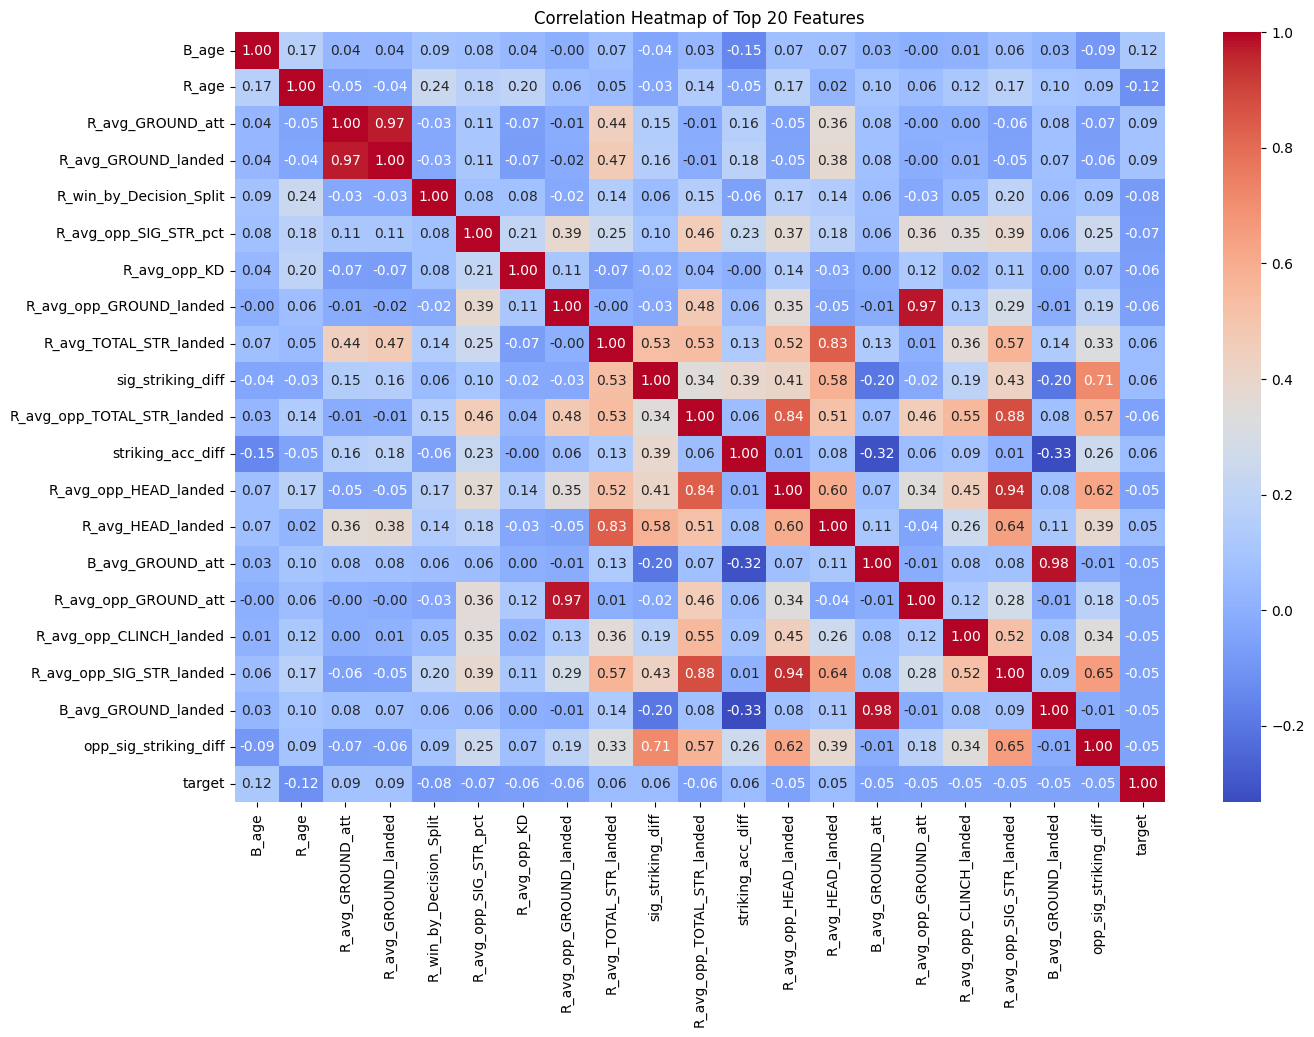

In [24]:
plt.figure(figsize=(15, 10))
sns.heatmap(ufc_viz_top_k.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Top 20 Features')
plt.show()

#### What does this tell me about the ```target``` feature? 
All of the values are very close to ```0``` indicating that there is very weak to no linear relationship between the features and ```target```. The highest correlation coefficients are $0.12$ and $-0.12$ (still very weak) that belong to ```B_age``` and ```R_age``` respectively. Those values aren't even striking metrics!

#### What does this tell me about inter-feature relationships?
Boxes that are very red 🔴 or very blue 🔵 show **high** correlations between each other and are a sign of multicollinearity (redundant). That's why we will use L1 (Lasso) regression model to automatically highlight the more predictive feature while shrinking the other.

### Box Plots
Determine if the engineered features might be predictive or not. ```opp_sig_striking_diff``` (the defensive feature) was the least predictive, so expect it reflect in the box plots. Remember, ```kd_differential``` feature didn't make the ```SelectKBest``` top 20, so I expect it to not be predictive for the ```target``` at all. 

*Note: Boxplots were made with the assistance of A.I. tools (Gemini).*

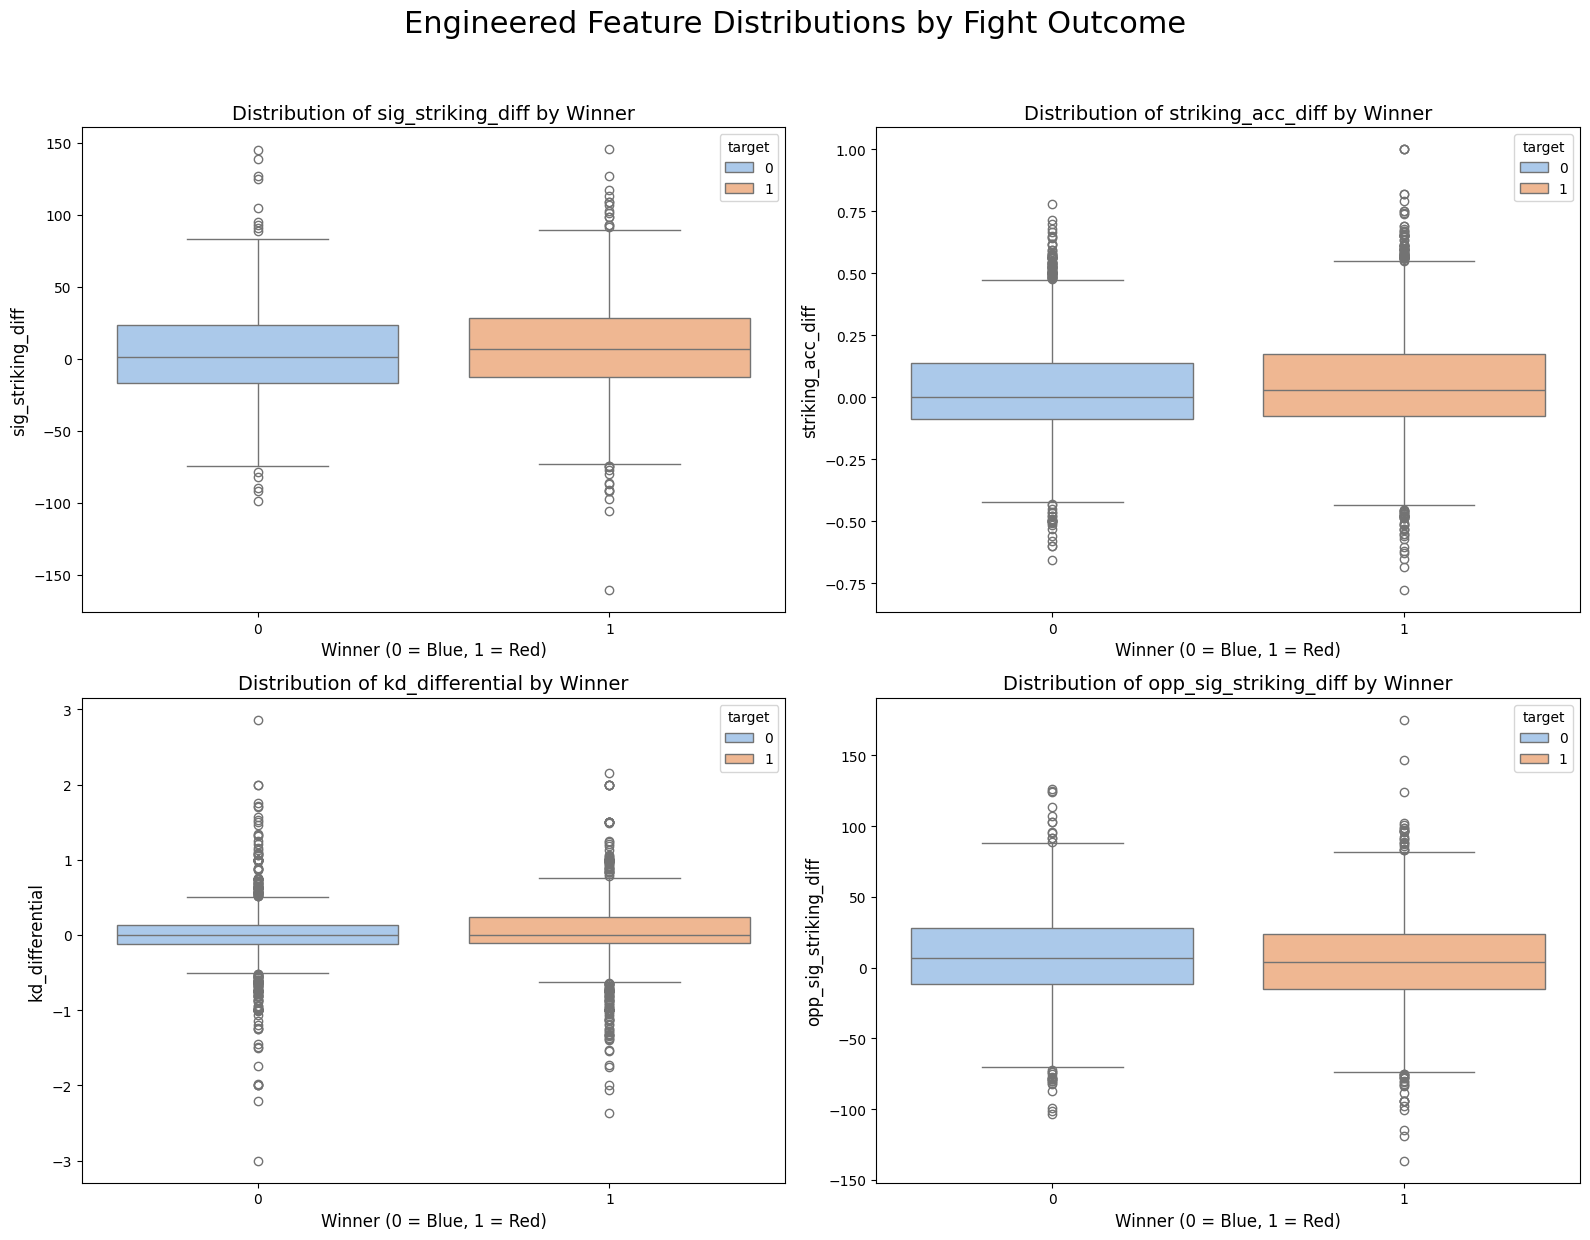

In [25]:
# --- Setup ---

# 1. List the exact names of the 4 features you want to plot
#    (Make sure these column names are in your DataFrame)
features_to_plot = [
    'sig_striking_diff',
    'striking_acc_diff',
    'kd_differential',
    'opp_sig_striking_diff' # This was your "defense" differential
]

# 2. Create a 2x2 grid of subplots.
#    figsize=(16, 12) makes the whole figure large enough to be readable.
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# 3. "Flatten" the 2x2 axes grid into a 1D array (axes[0], axes[1], etc.)
#    This makes it much easier to loop through.
axes = axes.flatten()

# --- Create the Plots with a Loop ---

# 4. Loop through each feature and its corresponding axis
for i, feature in enumerate(features_to_plot):
    
    # 5. Create the boxplot on the correct axis (axes[i])
    sns.boxplot(
        x='target',         # X-axis: Winner (0 or 1)
        y=feature,          # Y-axis: The differential feature
        data=ufc_viz,      # Your DataFrame
        ax=axes[i],         # *** This is the key part ***
        hue= 'target',      # Optional: Adds color by winner
        palette="pastel"    # Optional: Makes it look nice
    )
    
    # 6. Set a clear title and labels for each subplot
    axes[i].set_title(f'Distribution of {feature} by Winner', fontsize=14)
    axes[i].set_xlabel('Winner (0 = Blue, 1 = Red)', fontsize=12)
    axes[i].set_ylabel(f'{feature}', fontsize=12)

# --- Final Touches ---

# 7. Add a main title for the entire figure
fig.suptitle('Engineered Feature Distributions by Fight Outcome', fontsize=22, y=1.03)

# 8. Clean up the layout to prevent titles/labels from overlapping
plt.tight_layout()

# 9. Display the final figure
plt.show()

**How to read**: 

For the feature to be predictive: If blue 🟦 won the fight, then the majority of values should be negative. Inversely, if red 🟥 won the fight the majority of the values should be positive.

* Distribution of ```sig_striking_diff```: the means are in the correct locations. Somewhat predictive 🆗
* Distribution of ```striking_acc_diff```: the means are in the correct locations. Somewhat predictive 🆗
* Distribution of ```kd_differential```: Both 🟥 and 🟦 are centered at 0. Not predictive ⛔
* Distribution of ```opp_sig_striking_diff```: the mean diff of the 🟦 is positive (7.5) and higher than the 🟥 (4.4). Not predictive ⛔


In [26]:
ufc_viz['kd_differential'][ufc_viz_top_k['target'] == 0].mean()

np.float64(-0.0005475434292735958)

In [27]:
ufc_viz['kd_differential'][ufc_viz_top_k['target'] == 1].mean()

np.float64(0.030593854715266534)

### Bar chart of debutants


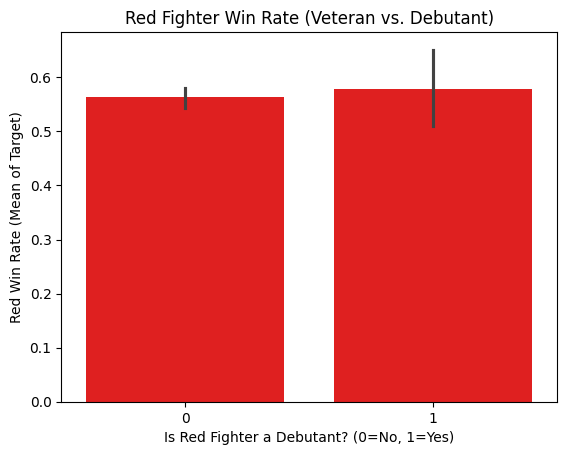

In [28]:
# Use the full ufc_data for this, not just df_for_viz
sns.barplot(data=ufc_data, x='R_is_debut', y='target', color='red')
plt.title('Red Fighter Win Rate (Veteran vs. Debutant)')
plt.ylabel('Red Win Rate (Mean of Target)')
plt.xlabel('Is Red Fighter a Debutant? (0=No, 1=Yes)')
plt.show()

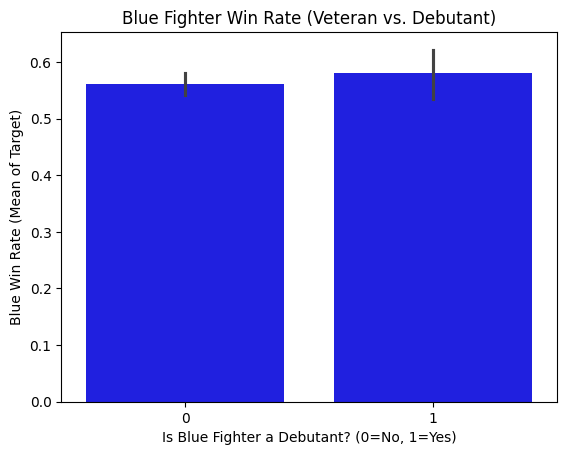

In [29]:
# Use the full ufc_data for this, not just df_for_viz
sns.barplot(data=ufc_data, x='B_is_debut', y='target', color='blue')
plt.title('Blue Fighter Win Rate (Veteran vs. Debutant)')
plt.ylabel('Blue Win Rate (Mean of Target)')
plt.xlabel('Is Blue Fighter a Debutant? (0=No, 1=Yes)')
plt.show()

# Modeling: Logistic Regression

In [30]:
y = ufc_data['target']
# Select only numeric columns for X
X = ufc_data.select_dtypes(include=[np.number])
# drop target from X
if 'target' in X.columns: 
    X = X.drop(columns='target')

X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2748 entries, 0 to 2747
Data columns (total 92 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   B_avg_KD                      2748 non-null   float64
 1   B_avg_opp_KD                  2748 non-null   float64
 2   B_avg_SIG_STR_pct             2748 non-null   float64
 3   B_avg_opp_SIG_STR_pct         2748 non-null   float64
 4   B_avg_SIG_STR_att             2748 non-null   float64
 5   B_avg_SIG_STR_landed          2748 non-null   float64
 6   B_avg_opp_SIG_STR_att         2748 non-null   float64
 7   B_avg_opp_SIG_STR_landed      2748 non-null   float64
 8   B_avg_TOTAL_STR_att           2748 non-null   float64
 9   B_avg_TOTAL_STR_landed        2748 non-null   float64
 10  B_avg_opp_TOTAL_STR_att       2748 non-null   float64
 11  B_avg_opp_TOTAL_STR_landed    2748 non-null   float64
 12  B_avg_HEAD_att                2748 non-null   float64
 13  B_avg_HE

## Train / Test Split

In [31]:
# Split data into training and testing sets
# 80/20, random_state=42, stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2198, 92)
X_test shape: (550, 92)
y_train shape: (2198,)
y_test shape: (550,)


## Scale features

In [32]:
from sklearn.preprocessing import RobustScaler

# initialize scaler
scaler = RobustScaler()

# fit scaler on X_train ONLY and transform
X_train_scaled = scaler.fit_transform(X_train)

# transform X_test using the scaler that was fit on X_train
X_test_scaled = scaler.transform(X_test)

print("Data successfully scaled using RobustScaler.")

Data successfully scaled using RobustScaler.


## Model Training

In [33]:
# Initialize the model with L1 (Lasso) penalty
# C=0.5 is a good starting point for regularization strength
model = LogisticRegression(
    penalty='l1', 
    C=0.5, 
    solver='liblinear', 
    random_state=42
)

# Train (fit) the model on SCALED training data
model.fit(X_train_scaled, y_train)

print("Model training complete.")

Model training complete.


## Features L1 Model Selected

In [34]:
# Get the feature names from original X
feature_names = X.columns

# Get the coefficients (weights) from the trained model
coefficients = model.coef_[0] # [0] because it's a binary classifier

# Create a DataFrame to see them clearly
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Filter for only the features the model *kept* (non-zero)
selected_features = coef_df[coef_df['Coefficient'] != 0]

print(f"Total features: {len(feature_names)}")
print(f"Features selected by L1 model: {len(selected_features)}")
print("\\n--- Selected Features and Their Importance (Coefficient) ---")

# Sort by absolute value to see the most important features at the top
selected_features_sorted = selected_features.reindex(
    selected_features['Coefficient'].abs().sort_values(ascending=False).index
)
print(selected_features_sorted)

Total features: 92
Features selected by L1 model: 57
\n--- Selected Features and Their Importance (Coefficient) ---
                        Feature  Coefficient
88                        B_age     0.397801
89                        R_age    -0.309331
73          R_avg_CLINCH_landed    -0.291148
81      R_win_by_Decision_Split    -0.245955
72             R_avg_CLINCH_att     0.228975
53       R_avg_TOTAL_STR_landed     0.215440
11   B_avg_opp_TOTAL_STR_landed    -0.190625
47        R_avg_opp_SIG_STR_pct    -0.180828
46            R_avg_SIG_STR_pct     0.161553
22            B_avg_opp_LEG_att     0.161015
58           R_avg_opp_HEAD_att     0.151849
19        B_avg_opp_BODY_landed     0.150864
76             R_avg_GROUND_att     0.144659
82  R_win_by_Decision_Unanimous     0.144315
71    R_avg_opp_DISTANCE_landed    -0.136017
43                 B_Weight_lbs    -0.116318
12               B_avg_HEAD_att    -0.115663
23         B_avg_opp_LEG_landed    -0.108923
59        R_avg_opp_HEAD_land

### Top 5 Striking features
1. ```R_avg_CLINCH_landed```    -0.291148

2. ```R_avg_CLINCH_att```   0.228975

3. ```R_avg_TOTAL_STR_landed```     0.215440

4. ```B_avg_opp_TOTAL_STR_landed```    -0.190625

5. ```R_avg_opp_SIG_STR_pct```    -0.180828


### Bottom 5 Striking features (that weren't dropped)
1. ```R_win_by_KO/TKO```    -0.009128

2. ```R_avg_opp_KD```    -0.005117
 
3. ```R_avg_KD```    -0.004448

4. ```R_avg_opp_LEG_landed```     0.002622

5. ```B_avg_GROUND_att```    -0.000202

# Evaluation

**Definition of Success**: A "good enough" model must perform significantly better than a naive baseline ([MachineLearningMastery](https://machinelearningmastery.com/naive-classifiers-imbalanced-classification-metrics/)) ([Medium](https://medium.com/@deepakbiswakarma2310/evaluation-metrics-for-logistic-regression-a-comprehensive-guide-ed6a44ccb0a5)). The primary goal will be to achieve an accuracy and F1-score that are better than simply betting on the fighter with the longer reach or the betting favorite, demonstrating that the striking-based model has true predictive power (or not).

[scikit learn: model evaluation documentation](https://scikit-learn.org/stable/modules/model_evaluation.html)

In [35]:
# 1. Make predictions on the scaled test data
y_pred = model.predict(X_test_scaled)

# 2. Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print("--- Model Evaluation ---")
print(f"Model Accuracy: {acc:.4f}")

# 3. Get the Classification Report (Precision, Recall, F1-Score)
print("\\n--- Classification Report ---")
# '0' is Blue Win, '1' is Red Win
print(classification_report(y_test, y_pred, target_names=['Blue Wins (0)', 'Red Wins (1)']))



--- Model Evaluation ---
Model Accuracy: 0.6236
\n--- Classification Report ---
               precision    recall  f1-score   support

Blue Wins (0)       0.60      0.42      0.50       240
 Red Wins (1)       0.64      0.78      0.70       310

     accuracy                           0.62       550
    macro avg       0.62      0.60      0.60       550
 weighted avg       0.62      0.62      0.61       550



## Accuracy

The overall percentage of correct predictions: 0.6236 or 62.4%.

Compare this to the *naive baseline*. There are 310 correct red 🟥 wins and a total of 550 total guesses. If the model just guessed red 🟥 everytime, it would be right 56.4% of the time.

$$ 62.4\%_{pred} > 56.4\%_{naive} $$

The model performs higher than the naive model.

In [36]:
310/550

0.5636363636363636

## Recall
Of all the actual wins of a class (red or blue), what percentage did the model successfully find?

🟦 Blue wins: $0.42$ This is the model's biggest weakness. It has a hard time predicting blue wins.

🟥 Red wins: $0.78$ The model did a good job predicting red wins.

## F1 Score

**STUDY** To provide a more nuanced look at performance, especially if the win/loss classes are imbalanced ([GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/)) 

*Quoted directly from D. Biswakarma on* ***Medium***: "The F1 score is the harmonic mean of precision and recall. It provides a balance between precision and recall, making it suitable when both false positives and false negatives need to be considered. The F1 score is highest when precision and recall are equal. The F1 score formula is:"([Medium](https://medium.com/@deepakbiswakarma2310/evaluation-metrics-for-logistic-regression-a-comprehensive-guide-ed6a44ccb0a5)).

$$ F1 = 2 * (Precision * Recall) / (Precision + Recall) $$

🟦 Blue's F1 score is $0.5$ which is no better than a coin toss. Not good 🚫.

🟥 Red's F1 score is $0.7$ which is awesome! 😃



## Confusion Matrix

**STUDY** To understand the specific types of errors the model makes (i.e., False Positives vs. False Negatives) ([GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/)) ([Medium](https://medium.com/@deepakbiswakarma2310/evaluation-metrics-for-logistic-regression-a-comprehensive-guide-ed6a44ccb0a5)).

* True Positives (241): Actual: Red Win, Predicted: Red Win

* True Negatives (102): Actual: Blue Win, Predicted: Blue Win

* False Positives (138) - (Type I Error): Actual: Blue Win, Predicted: Red Win

* False Negatives (69) - (Type II Error): Actual: Red Win, Predicted: Blue Win


\n--- Confusion Matrix ---


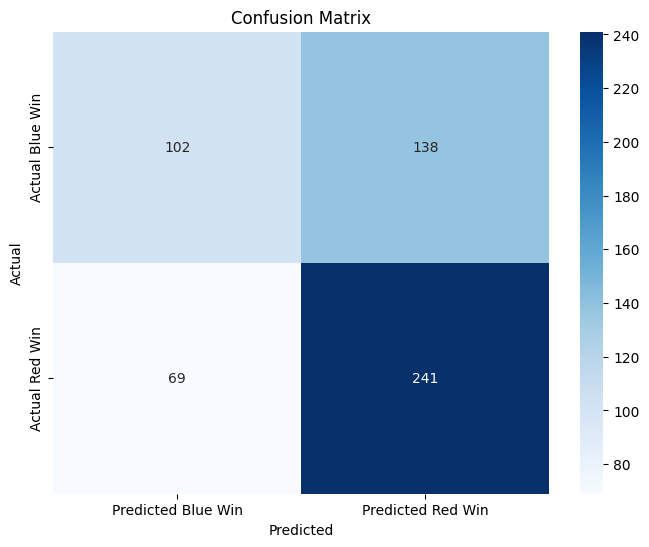

In [37]:
# Generate and Plot the Confusion Matrix
print("\\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Blue Win', 'Predicted Red Win'], 
            yticklabels=['Actual Blue Win', 'Actual Red Win'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Conclusion

This model is very good at identifying when Red🟥 will win based off his/her striking performance.
* Does great at finding red🟥 wins with $0.78$ recall.
* Overconfident in red🟥 wins based off the confusion matrix.
* Very biased toward red🟥 and struggles to find the pattern that leads to blue🟦 wins.

# References
Sources that I use but don't cite directly in the Notebook:

* Link to dataset's Kaggle page: [UFC-Fight historical data from 1993 to 2021](https://www.kaggle.com/datasets/rajeevw/ufcdata?select=data.csv)
* Direct link to dataset: [data.csv](https://www.kaggle.com/datasets/rajeevw/ufcdata?select=data.csv)
* Confusion Matrix: [GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/)
* Naive classifiers: [MachineLearningMastery](https://machinelearningmastery.com/naive-classifiers-imbalanced-classification-metrics/) 
* Evaluation methods for logistic regression: [Medium](https://medium.com/@deepakbiswakarma2310/evaluation-metrics-for-logistic-regression-a-comprehensive-guide-ed6a44ccb0a5)
* Scikit Learn model evaluation documentation: [scikit learn: model evaluation documentation](https://scikit-learn.org/stable/modules/model_evaluation.html)
* Getty images Alex Pereira vs Khalil Roundtree: https://www.ufc.com/news/alex-pereira-stand-and-deliver-ufc-313